<a href="https://colab.research.google.com/github/arunbalaji-ee/GEE/blob/main/spread_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Reading contour data...
2. Interpolating 3D Surface (this might take a moment)...


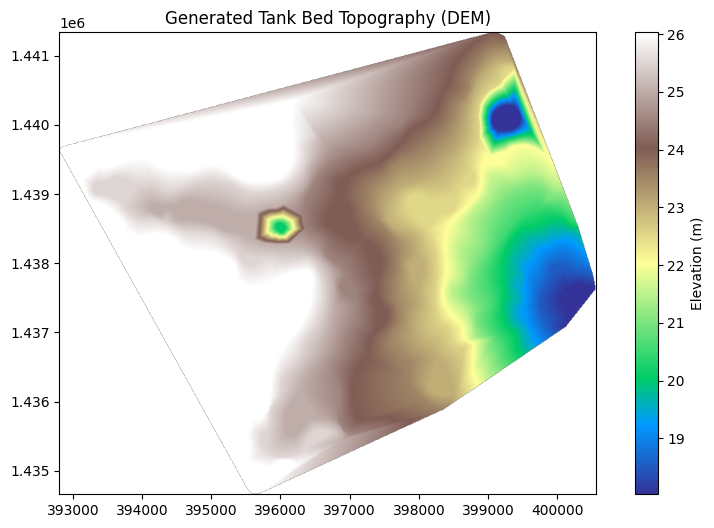

3. Calculating Volume for every 0.5m water rise...

✅ SUCCESS! Volume calculation complete.
Preview of your Lookup Table:
   Water_Level_m  Water_Spread_Area_m2     Volume_m3  Volume_TMC
0           19.0               1064300  6.156329e+05    0.000022
1           19.5               1532900  1.263950e+06    0.000045
2           20.0               2151800  2.184333e+06    0.000077
3           20.5               2775200  3.416592e+06    0.000121
4           21.0               3655900  5.013794e+06    0.000177


In [5]:
import geopandas as gpd
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
gdb_path = "/content/waterspread Detection.gdb"
layer_name = "contour"
elevation_col = "CONTOUR_ELEVATION" # The column we found!
resolution = 10  # 10 meter pixels (matches Sentinel-2 satellite)

# --- STEP 1: LOAD & PREPARE DATA ---
print("1. Reading contour data...")
gdf = gpd.read_file(gdb_path, layer=layer_name)

# Extract X, Y, Z points from the lines to build the 3D model
points_x = []
points_y = []
points_z = []

for _, row in gdf.iterrows():
    geom = row.geometry
    z = row[elevation_col]
    if geom.geom_type == 'MultiLineString':
        for line in geom.geoms:
            for point in line.coords:
                points_x.append(point[0])
                points_y.append(point[1])
                points_z.append(z)
    elif geom.geom_type == 'LineString':
        for point in geom.coords:
            points_x.append(point[0])
            points_y.append(point[1])
            points_z.append(z)

# --- STEP 2: CREATE 3D SURFACE (DEM) ---
print("2. Interpolating 3D Surface (this might take a moment)...")

# Define the grid (the "canvas" size)
x_min, x_max = min(points_x), max(points_x)
y_min, y_max = min(points_y), max(points_y)
grid_x, grid_y = np.mgrid[x_min:x_max:resolution, y_min:y_max:resolution]

# Interpolate (Fill in the gaps between lines)
dem_grid = griddata(
    (points_x, points_y),
    points_z,
    (grid_x, grid_y),
    method='linear'
)

# Plot the Result to verify
plt.figure(figsize=(10,6))
plt.imshow(dem_grid.T, extent=(x_min, x_max, y_min, y_max), origin='lower', cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.title("Generated Tank Bed Topography (DEM)")
plt.show()

# --- STEP 3: CALCULATE VOLUME AT EACH LEVEL ---
print("3. Calculating Volume for every 0.5m water rise...")

# Define water levels from bottom of tank to top
min_elev = np.nanmin(dem_grid)
max_elev = np.nanmax(dem_grid)
water_levels = np.arange(np.ceil(min_elev), np.floor(max_elev), 0.5)

results = []
pixel_area = resolution * resolution # 10m * 10m = 100 sq meters

for level in water_levels:
    # Logic: For every pixel deeper than the current level, add (Level - PixelDepth) * Area
    depth_map = level - dem_grid
    water_mask = depth_map > 0

    # Volume in Cubic Meters
    vol_m3 = np.sum(depth_map[water_mask]) * pixel_area

    # Area in Hectares
    area_m2 = np.sum(water_mask) * pixel_area

    results.append({
        "Water_Level_m": level,
        "Water_Spread_Area_m2": area_m2,
        "Volume_m3": vol_m3,
        "Volume_TMC": vol_m3 / 28316846592 # Convert to TMC (optional but standard)
    })

# --- STEP 4: SAVE THE LOOKUP TABLE ---
df_lookup = pd.DataFrame(results)
df_lookup.to_csv("AEC_Volume_Curve.csv", index=False)

print("\n✅ SUCCESS! Volume calculation complete.")
print("Preview of your Lookup Table:")
print(df_lookup.head())

In [6]:
import folium
import geopandas as gpd

# --- STEP 1: CONVERT TO GPS COORDINATES ---
# We use the previous 'gdf' variable.
# If you restarted Colab, reload the 'contour' layer first using the previous code.

print("Converting coordinates to Latitude/Longitude...")

# Reproject to EPSG:4326 (The standard for GPS/Google Maps)
# We handle the error if the original CRS is missing
if gdf.crs is None:
    print("⚠️ Warning: Original Coordinate System is missing.")
    print("I will assume it is UTM Zone 44N (Common for South India). If the map looks wrong, tell me!")
    gdf.set_crs(epsg=32644, inplace=True) # Guessing UTM 44N based on typical Indian data

gdf_gps = gdf.to_crs(epsg=4326)

# Get the center point of the tank
centroid = gdf_gps.geometry.centroid
center_lat = centroid.y.mean()
center_lon = centroid.x.mean()

print(f"✅ CENTER LOCATION DETECTED:")
print(f"Latitude:  {center_lat:.5f}")
print(f"Longitude: {center_lon:.5f}")

# --- STEP 2: SHOW ON INTERACTIVE MAP ---
print("\nGenerating Interactive Map...")
m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles='Esri.WorldImagery')

# Add the tank contours to the map
folium.GeoJson(
    gdf_gps,
    name="Tank Contours",
    style_function=lambda x: {'color': 'cyan', 'weight': 1}
).add_to(m)

# Show the map
m

Converting coordinates to Latitude/Longitude...
✅ CENTER LOCATION DETECTED:
Latitude:  13.00862
Longitude: 80.06145

Generating Interactive Map...


/tmp/ipython-input-4095800608.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf_gps.geometry.centroid


🛰️ Simulating Satellite Pass...
🔹 Detected Water Spread Area: 1781.57 Hectares

   💧 AUTOMATED WATER RESOURCE DASHBOARD
📅 Date:          2026-01-07 (Simulated)
🌊 Water Level:   25.06 m
🟦 Surface Area:  1781.57 Ha
📦 Volume (TMC):  0.0015 TMC
📊 Capacity:      85.0 % Full


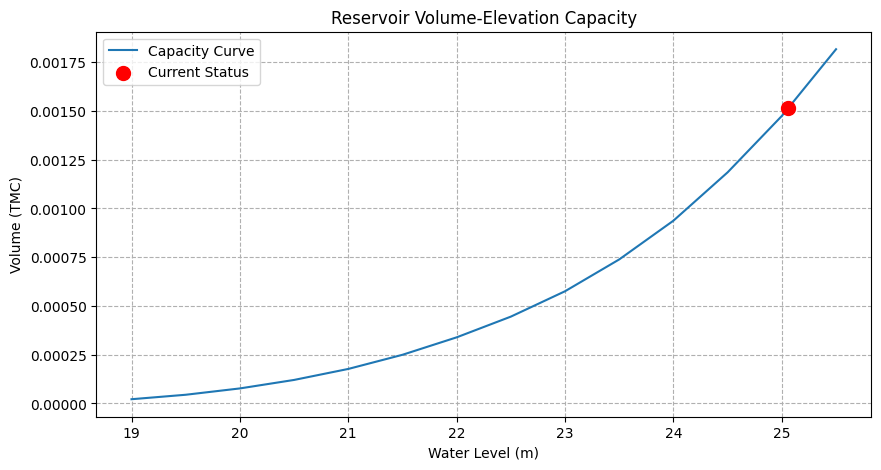

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. LOAD YOUR VOLUME CURVE ---
# We use the file we created in the previous step
df = pd.read_csv("AEC_Volume_Curve.csv")

# --- 2. SIMULATE SATELLITE DETECTION ---
print("🛰️ Simulating Satellite Pass...")

# Let's pretend the satellite detected 85% of the max area
max_area = df['Water_Spread_Area_m2'].max()
detected_area_m2 = max_area * 0.85

print(f"🔹 Detected Water Spread Area: {detected_area_m2/10000:.2f} Hectares")

# --- 3. CALCULATE VOLUME (INTERPOLATION) ---
# We look up this Area in our table to find the Volume
estimated_volume_m3 = np.interp(
    detected_area_m2,
    df['Water_Spread_Area_m2'],
    df['Volume_m3']
)

estimated_volume_tmc = estimated_volume_m3 / 28316846592
current_level = np.interp(detected_area_m2, df['Water_Spread_Area_m2'], df['Water_Level_m'])

# --- 4. GENERATE DASHBOARD REPORT ---
print("\n" + "="*40)
print("   💧 AUTOMATED WATER RESOURCE DASHBOARD")
print("="*40)
print(f"📅 Date:          2026-01-07 (Simulated)")
print(f"🌊 Water Level:   {current_level:.2f} m")
print(f"🟦 Surface Area:  {detected_area_m2/10000:.2f} Ha")
print(f"📦 Volume (TMC):  {estimated_volume_tmc:.4f} TMC")
print(f"📊 Capacity:      {(detected_area_m2 / max_area) * 100:.1f} % Full")
print("="*40)

# --- 5. PLOT THE TREND ---
plt.figure(figsize=(10,5))
plt.plot(df['Water_Level_m'], df['Volume_TMC'], label='Capacity Curve')
plt.scatter([current_level], [estimated_volume_tmc], color='red', s=100, label='Current Status', zorder=5)
plt.title("Reservoir Volume-Elevation Capacity")
plt.xlabel("Water Level (m)")
plt.ylabel("Volume (TMC)")
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

In [8]:
import os
import glob

# --- STEP 1: CLEAN UP OLD FILES ---
# We delete old .tif/.jp2 files so the code doesn't use the wrong "Medium" resolution ones
print("🧹 Cleaning up old satellite images...")
for f in glob.glob("*.tif") + glob.glob("*.tiff") + glob.glob("*.jp2"):
    try:
        os.remove(f)
    except:
        pass

# --- STEP 2: FIND AND UNZIP ---
zip_files = glob.glob("*.zip")

if len(zip_files) > 0:
    # Pick the most recently uploaded zip
    latest_zip = max(zip_files, key=os.path.getctime)
    print(f"📦 Found zip file: {latest_zip}")
    print("Unzipping...")

    # Unzip (-o overwrites without asking, -j flattens folders so files are easier to find)
    !unzip -o -j "$latest_zip"

    print("✅ Unzip Complete! Your TIF files are ready.")
else:
    print("❌ Error: No .zip file found. Did you upload it to the Files sidebar?")

🧹 Cleaning up old satellite images...
📦 Found zip file: Browser_images.zip
Unzipping...
Archive:  Browser_images.zip
 extracting: 2025-07-30-00:00_2025-07-30-23:59_Sentinel-2_L2A_B03_(Raw).tiff  
 extracting: 2025-07-30-00:00_2025-07-30-23:59_Sentinel-2_L2A_B11_(Raw).tiff  
✅ Unzip Complete! Your TIF files are ready.


🔍 Searching for satellite images...
✅ Found Green Band: 2025-07-30-00:00_2025-07-30-23:59_Sentinel-2_L2A_B03_(Raw).tiff
✅ Found SWIR Band:  2025-07-30-00:00_2025-07-30-23:59_Sentinel-2_L2A_B11_(Raw).tiff

🌊 Processing Satellite Image...
🔹 Detected Water Area: 1195.48 Hectares

📊 Calculating Volume from Lookup Table...

   🚀 FINAL AUTOMATED RESERVOIR REPORT
📅 Status:          LIVE SATELLITE DATA
🌊 Water Level:     23.89 meters
🟦 Surface Area:    1195.48 Hectares
📦 Current Volume:  0.0009 TMC
🔋 Storage Status:  49.1 % Full


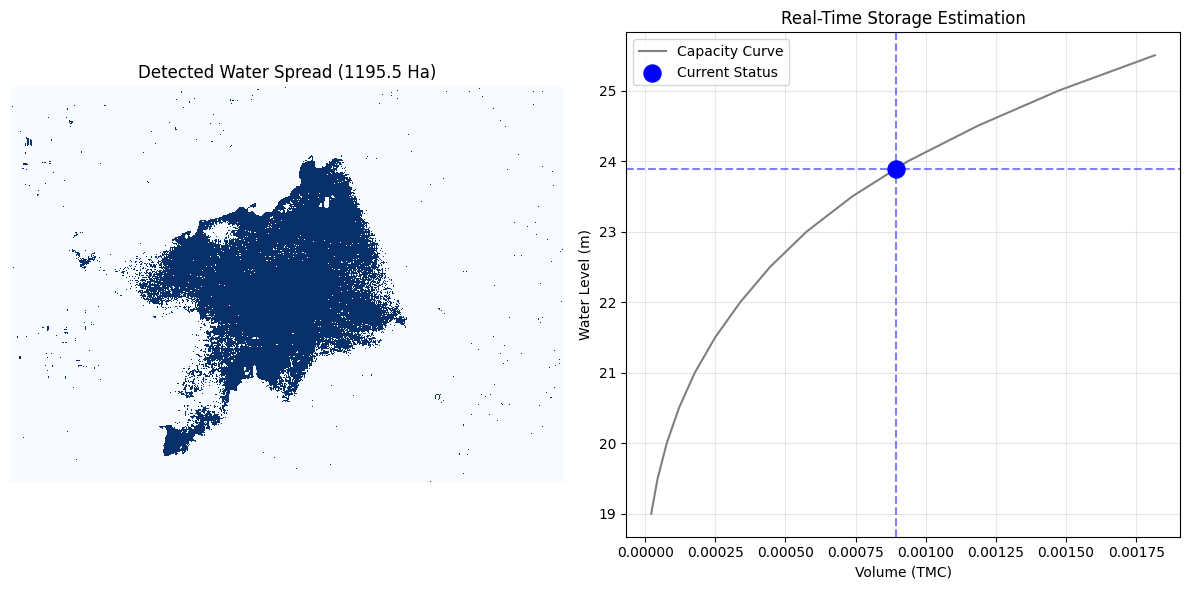

In [9]:
import os
import glob
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- STEP 1: AUTO-DETECT THE SATELLITE BANDS ---
print("🔍 Searching for satellite images...")

# Look for tiff, tif, or jp2 files
image_files = glob.glob("*.tiff") + glob.glob("*.tif") + glob.glob("*.jp2")

b03_path = None
b11_path = None

for f in image_files:
    if "B03" in f:
        b03_path = f
    elif "B11" in f:
        b11_path = f

if b03_path and b11_path:
    print(f"✅ Found Green Band: {b03_path}")
    print(f"✅ Found SWIR Band:  {b11_path}")
else:
    raise SystemExit("❌ ERROR: Could not find B03 and B11 files. Make sure you unzipped the file!")

# --- STEP 2: CALCULATE WATER SPREAD (MNDWI) ---
print("\n🌊 Processing Satellite Image...")

with rasterio.open(b03_path) as src:
    green = src.read(1).astype('float32')
    profile = src.profile # Save metadata

with rasterio.open(b11_path) as src:
    # Resize SWIR to match Green (just in case resolutions differ)
    swir = src.read(
        1,
        out_shape=(src.count, green.shape[0], green.shape[1]),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype('float32')

# Calculate MNDWI Index
# Formula: (Green - SWIR) / (Green + SWIR)
epsilon = 1e-10 # Prevent division by zero
mndwi = (green - swir) / (green + swir + epsilon)

# Threshold: Water is usually > 0.1
water_mask = mndwi > 0.1
water_pixels = np.sum(water_mask)

# Calculate Area (Each pixel is 10m x 10m = 100 sq meters)
water_area_m2 = water_pixels * 100
water_area_ha = water_area_m2 / 10000

print(f"🔹 Detected Water Area: {water_area_ha:.2f} Hectares")

# --- STEP 3: ESTIMATE VOLUME (DASHBOARD) ---
print("\n📊 Calculating Volume from Lookup Table...")

# Check if the curve file exists
if not os.path.exists("AEC_Volume_Curve.csv"):
    raise SystemExit("❌ ERROR: 'AEC_Volume_Curve.csv' not found. Please run the Volume Calculation code again!")

df = pd.read_csv("AEC_Volume_Curve.csv")

# Interpolate Volume based on the real Satellite Area
estimated_vol_tmc = np.interp(water_area_m2, df['Water_Spread_Area_m2'], df['Volume_TMC'])
current_level = np.interp(water_area_m2, df['Water_Spread_Area_m2'], df['Water_Level_m'])
max_vol = df['Volume_TMC'].max()

# --- STEP 4: FINAL DASHBOARD OUTPUT ---
print("\n" + "="*50)
print("   🚀 FINAL AUTOMATED RESERVOIR REPORT")
print("="*50)
print(f"📅 Status:          LIVE SATELLITE DATA")
print(f"🌊 Water Level:     {current_level:.2f} meters")
print(f"🟦 Surface Area:    {water_area_ha:.2f} Hectares")
print(f"📦 Current Volume:  {estimated_vol_tmc:.4f} TMC")
print(f"🔋 Storage Status:  {(estimated_vol_tmc / max_vol) * 100:.1f} % Full")
print("="*50)

# --- STEP 5: VISUALIZATION ---
plt.figure(figsize=(12, 6))

# Plot 1: The Water Map
plt.subplot(1, 2, 1)
plt.imshow(water_mask, cmap='Blues', interpolation='nearest')
plt.title(f"Detected Water Spread ({water_area_ha:.1f} Ha)")
plt.axis('off')

# Plot 2: The Volume Graph
plt.subplot(1, 2, 2)
plt.plot(df['Volume_TMC'], df['Water_Level_m'], label='Capacity Curve', color='gray')
plt.scatter([estimated_vol_tmc], [current_level], color='blue', s=150, label='Current Status', zorder=5)
plt.axhline(current_level, color='blue', linestyle='--', alpha=0.5)
plt.axvline(estimated_vol_tmc, color='blue', linestyle='--', alpha=0.5)
plt.xlabel("Volume (TMC)")
plt.ylabel("Water Level (m)")
plt.title("Real-Time Storage Estimation")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
import geopandas as gpd

# 1. Load the Contour Layer
# Note: We use the path you found in the previous step
gdb_path = "/content/waterspread Detection.gdb"
layer_name = "contour"

print(f"Loading {layer_name}...")
gdf = gpd.read_file(gdb_path, layer=layer_name)

# 2. Show the Column Names
print("\n--- COLUMN NAMES ---")
print(gdf.columns.tolist())

# 3. Show the first 5 rows (to check the data)
print("\n--- FIRST 5 ROWS ---")
print(gdf.head())

# 4. Check for Geometry Type (LineString or Polygon?)
# Volume calculation is different if they are lines vs closed polygons
print("\n--- GEOMETRY TYPE ---")
print(gdf.geom_type.unique())

Loading contour...

--- COLUMN NAMES ---
['CONTOUR_ELEVATION', 'CONTOUR_ELEVATION_1', 'SHAPE_Length', 'geometry']

--- FIRST 5 ROWS ---
   CONTOUR_ELEVATION  CONTOUR_ELEVATION_1  SHAPE_Length  \
0          20.530001                  NaN   2811.450872   
1          22.530001                  NaN   5828.253919   
2          24.030001                  NaN   8185.233094   
3          23.530001                  NaN   6794.866764   
4          23.030001                  NaN   7194.967018   

                                            geometry  
0  MULTILINESTRING ((399155.706 1436949.947, 3991...  
1  MULTILINESTRING ((398671.701 1436794.332, 3986...  
2  MULTILINESTRING ((397121.52 1435721.392, 39709...  
3  MULTILINESTRING ((398358.079 1435882.012, 3983...  
4  MULTILINESTRING ((398517.325 1436075.825, 3984...  

--- GEOMETRY TYPE ---
['MultiLineString']


In [3]:
import os
import fiona

# --- STEP 1: INSTALL TOOLS ---
!pip install -q geopandas fiona

# --- STEP 2: UNZIP (Force Overwrite) ---
# The '-o' flag forces it to overwrite without asking you questions
zip_path = "/content/OneDrive_2026-01-06.zip"

print(f"Unzipping {zip_path}...")
!unzip -o -q "$zip_path"
print("Unzip complete! (No questions asked)\n")

# --- STEP 3: FIND THE DATABASE ---
found_gdb_path = None
for root, dirs, files in os.walk("/content"):
    for dir_name in dirs:
        if dir_name.endswith(".gdb"):
            found_gdb_path = os.path.join(root, dir_name)
            break
    if found_gdb_path: break

# --- STEP 4: PRINT LAYER NAMES ---
if found_gdb_path:
    print(f"✅ FOUND DATABASE AT: {found_gdb_path}")
    print("-" * 40)
    try:
        layers = fiona.listlayers(found_gdb_path)
        for i, name in enumerate(layers):
            print(f"Layer {i+1}: {name}")
    except Exception as e:
        print(f"Error reading layers: {e}")
    print("-" * 40)
else:
    print("❌ ERROR: Could not find the .gdb folder.")

Unzipping /content/OneDrive_2026-01-06.zip...
Unzip complete! (No questions asked)

✅ FOUND DATABASE AT: /content/waterspread Detection.gdb
----------------------------------------
Layer 1: TANK_BOUNDARY
Layer 2: contour
----------------------------------------
